# 클러스터링(Clustering) — 비지도학습

**핵심 질문**: 정답(Label)이 없을 때, 데이터 스스로 어떤 구조를 드러내는가?

**오늘의 목표**
1. **지도 vs 비지도 학습**: 정답의 유무가 만드는 학습 구조의 차이
2. **거리와 유사도**: 군집의 기준 — 유클리드, 맨해튼, 코사인
3. **K-Means**: 중심(Centroid) 기반 반복 군집화의 원리와 수렴 과정
4. **K값 선택**: Elbow Method + Silhouette Score로 최적 K를 데이터로 결정
5. **Iris 군집화**: 정답 없이도 데이터 구조를 발견할 수 있는가?
6. **고객 세분화**: 군집 결과를 비즈니스 그룹과 전략으로 연결
7. **알고리즘 비교**: K-Means · DBSCAN · Hierarchical · GMM · MeanShift의 특성과 선택 기준
8. **실무 응용**: Pipeline, 이상치 탐지(DBSCAN + IQR), 유사 고객 추천
9. **PCA + 군집**: 고차원 데이터를 2D/3D로 투영하여 구조 시각화

**예제**: Iris (K-Means 군집화 vs 정답 비교), 가상 고객 데이터 (세분화 · 이상치 탐지 · 추천), 인공 형태 데이터 (5가지 알고리즘 비교)

---
## 지도학습 복습 → 비지도학습으로의 전환

지금까지 배운 지도학습 알고리즘들:

| 알고리즘 | 핵심 아이디어 | 정답(Label) |
|---------|-------------|:-----------:|
| 로지스틱 회귀 | 확률 → 분류 | **있음** |
| KNN | 가까운 이웃 다수결 | **있음** |
| 결정 트리 | if-else 규칙 분류 | **있음** |
| 앙상블 (RF / Boosting) | 여러 트리의 합의 | **있음** |
| **군집(Clustering)** | 비슷한 것끼리 묶음 | **없음** |

> 지도학습: "정답을 알려주면 패턴을 찾는다"  
> **비지도학습: "정답 없이 데이터 스스로 구조를 드러낸다"**

### 왜 비지도학습이 필요한가?

현실 데이터의 대부분은 **정답(Label)이 없음**:
- 고객 구매 이력 → "이 고객은 어떤 유형인가?" (정답 없음)
- 뉴스 기사 수만 건 → "주제별로 자동 분류" (정답 없음)
- 유전자 발현 데이터 → "어떤 유전자가 함께 작동하는가?" (정답 없음)

> **라벨을 만드는 비용이 너무 크거나, 애초에 정답이 정해져 있지 않은 경우**  
> → 비지도학습으로 데이터에서 직접 구조를 발견해야 함!

#  Phase 1 — 지도 vs 비지도학습

## 목표

- 지도학습과 비지도학습의 구조적 차이를 이해
- Label(정답)의 유무가 학습에 미치는 영향 인지
- Plotly로 Label이 있는 데이터 vs 없는 데이터를 비교 시각화
- 정답이 없어도 구조는 존재


## 1. 지도학습 vs 비지도학습 — 개념 비교

| 항목 | 지도학습 (Supervised) | 비지도학습 (Unsupervised) |
|---|---|---|
| 데이터 | 입력 **X** + 정답 **y** | 입력 **X** 만 존재 |
| 목표 | 예측 (Predict) | 패턴 발견 (Discover Structure) |
| 출력 | 분류 / 회귀 | 군집 / 차원축소 |
| 학습 방식 | 정답 피드백 기반 | 데이터 간 관계 기반 |
| 예시 | 스팸 분류, 매출 예측 | 고객 세분화, 이상치 탐지 |

> 핵심
> 지도학습은 **답을 맞히는 기술**, 비지도학습은 **질문을 발견하는 기술**이

## **2 시각적 비교 - “정답이 사라지면 무슨 일이 생길까?”**

**포인트**
- **왼쪽**: 색으로 구분된 세 그룹 → 정답(Label)이 있는 세계
- **오른쪽**: 모든 점이 같은 색 → 정답 부재 세계
- **그러나** 여전히 세 덩어리로 모여 있는 패턴이 보인다 → **데이터 자체의 구조**

In [1]:
import numpy as np
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.datasets import make_blobs

np.random.seed(42)

X_label, y_label = make_blobs(n_samples=200, centers=3, cluster_std=0.9, random_state=42)
X_unlabel = X_label.copy()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("지도학습 (Label 있음)", "비지도학습 (Label 없음)")
)

fig_left = px.scatter(
    x=X_label[:, 0], y=X_label[:, 1],
    color=y_label.astype(str),
    color_discrete_sequence=px.colors.qualitative.Bold,
    template="plotly_dark"
)
for tr in fig_left.data:
    fig.add_trace(tr, row=1, col=1)

fig_right = px.scatter(
    x=X_unlabel[:, 0], y=X_unlabel[:, 1],
    opacity=0.9, color_discrete_sequence=["#00FFFF"],
    template="plotly_dark"
)
fig.add_trace(fig_right.data[0], row=1, col=2)

fig.update_layout(
    template="plotly_dark",
    width=980, height=460,
    title_text="지도 vs 비지도학습 - Label 유무에 따른 데이터 구조 비교",
    showlegend=False
)
fig.update_xaxes(title_text="Feature 1", row=1, col=1)
fig.update_yaxes(title_text="Feature 2", row=1, col=1)
fig.update_xaxes(title_text="Feature 1", row=1, col=2)
fig.update_yaxes(title_text="Feature 2", row=1, col=2)

fig.show()

**포인트**
- **왼쪽**: 색으로 구분된 세 그룹 → 정답(Label)이 있는 세계
- **오른쪽**: 모든 점이 같은 색 → 정답 부재 세계
- **그러나** 여전히 세 덩어리로 모여 있는 패턴이 보인다 → **데이터 자체의 구조**

## **3 핵심 인사이트 - “정답이 없어도, 구조는 존재한다.”**

> 비지도학습은 라벨이 없어도, **데이터가 스스로 말하도록 만드는 과정**

## **4 왜 비지도학습이 중요한가?**

| 분야 | 활용 예시 | 설명 |
|---|---|---|
| 마케팅 | 고객 세분화 | 비슷한 구매 패턴끼리 묶기 |
| 금융 | 이상치 탐지 | 사기 거래, 비정상 패턴 감지 |
| 추천 | 콘텐츠 추천 | 유사 취향 사용자 찾기 |
| 데이터분석 | 차원축소 / 전처리 | 복잡한 구조 단순화 |

> 정답 없이도 **패턴의 힘**으로 문제를 해결할 수 있으며,
> 세상에는 정답이 없는 경우가 많당

## **요약**
- 지도학습 → 정답(Label) 기반 예측
- 비지도학습 → 정답 없이 구조 탐색
- Label이 없어도 데이터 패턴은 존재
- 군집 = 정답 없는 패턴 발견

# Phase 2 - 거리(Distance)와 유사도(Similarity)

---

## 목표

- 거리(distance)와 유사도(similarity)가 비지도학습의 핵심 기준임을 이해
- Euclidean, Manhattan, Cosine 거리 계산 비교
- 거리와 각도(유사도) 이해
- 가까울수록 비슷하고 멀수록 다르다는 개념 정립

## 거리의 개념

| 거리 측정법 | 개념 | 직관적 의미 | 사용 예시 |
|---|---|---|---|
| Euclidean Distance | √((x₁−x₂)²+(y₁−y₂)²) | 두 점 사이 직선거리 | 지도상 거리 |
| Manhattan Distance | | | |
| Cosine Similarity | cos(θ)=A·B/(‖A‖‖B‖) | 방향의 유사도 | 추천 시스템 |

비슷한 데이터일수록 가깝고 멀다는 것은 다르다는 의미

## 핵심

> 정답이 없는 데이터에서 모델은 무엇을 근거로 그룹을 나누는가
> 기준은 거리와 닮음



## 2. 유클리드 거리

In [2]:
import numpy as np
import plotly.graph_objects as go

points = np.array([[1, 1], [4, 1], [4, 4]])
labels = ["A(1,1)", "B(4,1)", "C(4,4)"]

def euclidean(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

dist_AB = euclidean(points[0], points[1])
dist_BC = euclidean(points[1], points[2])
dist_AC = euclidean(points[0], points[2])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=points[:,0], y=points[:,1],
    mode="markers+text", text=labels, textposition="top right",
    marker=dict(size=10, color="cyan"), name="Points"
))
fig.add_trace(go.Scatter(x=[1,4], y=[1,1], mode="lines+text",
                         text=[f"{dist_AB:.2f}"], textposition="top center",
                         line=dict(color="magenta", dash="dot"), name="AB"))
fig.add_trace(go.Scatter(x=[4,4], y=[1,4], mode="lines+text",
                         text=[f"{dist_BC:.2f}"], textposition="top center",
                         line=dict(color="orange", dash="dot"), name="BC"))
fig.add_trace(go.Scatter(x=[1,4], y=[1,4], mode="lines+text",
                         text=[f"{dist_AC:.2f}"], textposition="bottom center",
                         line=dict(color="yellow", dash="dot"), name="AC"))
fig.update_layout(
    title="Euclidean Distance — 두 점 사이의 직선거리",
    xaxis_title="X", yaxis_title="Y", template="plotly_dark",
    width=650, height=450
)
fig.show()

- A–B, B–C, A–C 간 거리값이 직선으로 표현
- A–C가 가장 길며, 유클리드 거리의 핵심은 직선이 가장 짧은 경로라는 점
- K-Means는 이 거리를 기준으로 가장 가까운 중심을 계산

- 민감해 : 스케일링(표준화)

## 3.맨해튼 거리
- Manhattan 거리는 x축과 y축을 따라 이동하는 거리로 A→C는 6 단위
- 직선이 아닌 격자 이동 기준의 거리로 도시 블록 형태의 이동 모델 등에서 사용

In [3]:
def manhattan(p1, p2):
    return np.sum(np.abs(p1 - p2))

m_AB = manhattan(points[0], points[1])
m_BC = manhattan(points[1], points[2])
m_AC = manhattan(points[0], points[2])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[1,4,4], y=[1,1,4],
    mode="lines+markers+text",
    text=["", f"{m_AC:.1f}", ""],
    textposition="middle right",
    line=dict(color="magenta", dash="dot", width=3),
    marker=dict(size=8, color="white"),
    name="Manhattan Path"
))
fig.update_layout(
    title="Manhattan Distance - 격자 경로 거리",
    xaxis_title="X", yaxis_title="Y", template="plotly_dark",
    width=650, height=450
)
fig.show()

## 4. 코사인 유사도 - 크기가 아닌 방향(각도)

In [4]:
from numpy import dot
from numpy.linalg import norm

v1 = np.array([3, 2])
v2 = np.array([2, 3])
cos_sim = dot(v1, v2) / (norm(v1) * norm(v2))

fig = go.Figure()
fig.add_trace(go.Scatter(x=[0, v1[0]], y=[0, v1[1]],
                         mode="lines+text", text=["v1"], textposition="top center",
                         line=dict(color="cyan", width=4), name="v1"))
fig.add_trace(go.Scatter(x=[0, v2[0]], y=[0, v2[1]],
                         mode="lines+text", text=["v2"], textposition="top center",
                         line=dict(color="magenta", width=4), name="v2"))
fig.add_shape(type="circle", xref="x", yref="y",
              x0=-4, y0=-4, x1=4, y1=4,
              line=dict(color="gray", dash="dot"))
fig.update_layout(
    title=f"Cosine Similarity = {cos_sim:.3f}",
    xaxis=dict(range=[0,4]), yaxis=dict(range=[0,4]),
    template="plotly_dark", width=600, height=500
)
fig.show()

- Cosine 유사도는 벡터 간 방향의 닮음을 측정
- 값은 1에 가까울수록 방향이 같음 추천 시스템 등에서 취향 패턴 유사도 비교에 활용

## 거리와 유사도 요약

| 개념 | 크면 의미 | 작으면 의미 | 대표 알고리즘 |
|---|---|---|---|
| Distance | 서로 멂 | 서로 가까움 | K-Means, Hierarchical |
| Similarity | 서로 비슷함 | 서로 다름 | Cosine 기반 추천 시스템 |

Distance는 차이의 언어, Similarity는 닮음의 언어

### 참고 — 거리/유사도 선택 가이드

| **데이터 상황** | **추천 거리/모델 기준** | **왜 적합한가? (해석 포인트)** |
|----------------|------------------------|------------------------------|
| 원형·볼록 군집 (연속형 수치), 평균 중심 기반 분포 | **Euclidean (L2)** | 직선 거리 기준 → 중심(Centroid) 기반 K-Means와 자연스럽게 연결 |
| 축 방향 이동 비용이 중요 (격자 구조, L1 규제 직관) | **Manhattan (L1)** | 절댓값 합산 → 축 방향 편차를 직접 반영, 이상치에 L2보다 덜 민감 |
| 취향/패턴 유사도 (평점, 텍스트 TF-IDF, 벡터 표현) | **Cosine Similarity** | 크기보다 방향(패턴)이 중요 → “어느 방향을 보는가”가 핵심 |
| 비정형 구조 + 노이즈 포함 (모양 자유로운 군집) | **DBSCAN (eps + 거리 기준)** | 반경(eps) 안의 밀도 기반 연결 → 중심 가정 없이 자유로운 모양 탐지 |
| 겹침 허용, 타원형 분포, 확률적 소속 필요 | **Mahalanobis / GMM** | 공분산을 고려한 거리 → 타원형 구조 표현 및 Soft Clustering 가능 |

# Phase 3 — K-Means 원리

## 목표

- K-Means가 중심(Centroid)을 기준으로 데이터를 분류하는 원리 이해
- 중심 설정 → 거리 계산 → 재할당 → 중심 갱신 과정 구현 및 시각화
- 중심 이동 과정을 시각적으로 확인하여 수렴 원리 체득
- 데이터가 스스로 중심을 찾는 비지도학습의 본질 이해

## 정리

- 정답이 없는 상황에서 모델은 데이터를 어떻게 묶는가
- K-Means는 각 데이터를 가장 가까운 중심(Centroid)으로 배정하고,
- 중심을 팀원들의 평균 위치로 이동시키며 수렴하는 알고리즘

## 1. K-Means의 핵심 아이디어

| 단계 | 과정 | 설명 |
|---|---|---|
| 1 | 초기 중심 설정 | 무작위로 k개의 중심(Centroid) 선택 |
| 2 | 거리 계산 및 군집 할당 | 각 데이터가 가장 가까운 중심에 배정 |
| 3 | 중심 갱신 | 각 군집의 평균 위치로 중심 이동 |
| 4 | 수렴 | 중심 이동이 거의 없을 때 멈춤 |

> 가장 가까운 중심으로 데이터가 모이고, 중심은 평균 위치로 이동


## 초기 중심 지정

In [5]:
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=100, centers=3, cluster_std=1.0, random_state=42)

k = 3
np.random.seed(42)
initial_idx = np.random.choice(len(X), k, replace=False)
centroids = X[initial_idx]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1],
    mode="markers",
    marker=dict(color="white", size=6, line=dict(color="gray", width=1))
))
fig.add_trace(go.Scatter(
    x=centroids[:,0], y=centroids[:,1],
    mode="markers+text",
    text=[f"C{i}" for i in range(k)],
    textposition="bottom center",
    marker=dict(size=14, color=["cyan","magenta","orange"], symbol="x")
))
fig.update_layout(
    title="Step 0 — 초기 중심 (랜덤 선택)",
    xaxis_title="X1", yaxis_title="X2", template="plotly_dark",
    width=650, height=450
)
fig.show()

- 초기 중심은 무작위로 선택
- 이 점들이 리더 역할을 하며 반복적으로 이동하면서 중심이 안정화

In [6]:
from scipy.spatial.distance import cdist

distances = cdist(X, centroids)
clusters = np.argmin(distances, axis=1)

colors = np.array(["cyan", "magenta", "orange"])
cluster_colors = [colors[i] for i in clusters]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1],
    mode="markers",
    marker=dict(color=cluster_colors, size=6)
))
fig.add_trace(go.Scatter(
    x=centroids[:,0], y=centroids[:,1],
    mode="markers+text",
    text=[f"C{i}" for i in range(k)],
    textposition="bottom center",
    marker=dict(size=14, color=colors, symbol="x")
))
fig.update_layout(
    title="Step 1 — 가장 가까운 중심으로 데이터 할당",
    xaxis_title="X1", yaxis_title="X2", template="plotly_dark",
    width=650, height=450
)
fig.show()

- 각 점은 자신과 가장 가까운 중심 속함
- 이 단계에서 데이터는 거리 기반으로 첫 번째 그룹을 형성
- 거리 개념이 K-Means의 핵심 작동 원리

In [7]:
new_centroids = np.array([X[clusters == i].mean(axis=0) for i in range(k)])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1],
    mode="markers",
    marker=dict(color=cluster_colors, size=6)
))
fig.add_trace(go.Scatter(
    x=centroids[:,0], y=centroids[:,1],
    mode="markers+text",
    text=[f"Old C{i}" for i in range(k)],
    textposition="bottom right",
    marker=dict(size=14, color=colors, symbol="x", line=dict(width=2,color="white"))
))
fig.add_trace(go.Scatter(
    x=new_centroids[:,0], y=new_centroids[:,1],
    mode="markers+text",
    text=[f"New C{i}" for i in range(k)],
    textposition="top left",
    marker=dict(size=14, color=colors, symbol="star", line=dict(width=2,color="yellow"))
))
fig.update_layout(
    title="Step 2 — 중심의 이동 (평균 위치로 갱신)",
    xaxis_title="X1", yaxis_title="X2", template="plotly_dark",
    width=650, height=450
)
fig.show()

centroids = new_centroids

- 별 표시는 새 중심, X 표시는 이전 중심
- 중심은 팀원들의 평균 위치로 이동
- 평균점은 군집 내부 오차제곱합(RSS)을 최소화하는 위치

In [8]:
centroids = X[np.random.choice(len(X), k, replace=False)]
for step in range(5):
    distances = cdist(X, centroids)
    clusters = np.argmin(distances, axis=1)
    new_centroids = np.array([X[clusters == i].mean(axis=0) for i in range(k)])

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=X[:,0], y=X[:,1],
        mode="markers",
        marker=dict(color=[colors[i] for i in clusters], size=6)
    ))
    fig.add_trace(go.Scatter(
        x=centroids[:,0], y=centroids[:,1],
        mode="markers+text",
        text=[f"Step {step} C{i}" for i in range(k)],
        textposition="bottom center",
        marker=dict(size=14, color=colors, symbol="x", line=dict(width=2,color="white"))
    ))
    fig.update_layout(
        title=f"Iteration Step {step}",
        xaxis_title="X1", yaxis_title="X2", template="plotly_dark",
        width=650, height=450
    )
    fig.show()
    centroids = new_centroids

- 반복할수록 중심 이동 거리가 줄어들고,
- 데이터의 색상 경계가 안정화되며 군집이 명확하게 수렴
- 이 과정이 데이터의 자기조직화(Self-organizing)

## 정리

| 개념 | 의미 |
|---|---|
| 중심(Centroid) | 군집의 대표 좌표 |
| 거리 기반 할당 | 각 점은 가장 가까운 중심에 속함 |
| 반복 갱신 | 중심 → 재할당 → 중심 이동 반복 |
| 수렴 | 중심 이동이 거의 없을 때 멈춤 |

K-Means는 데이터가 스스로 중심을 찾아가는 자기조직화(Self-organizing) 알고리즘

### K-Means: 가장 가까운 중심으로 모이는데, 중심은 평균으로 이동
- 무질서한 데이터 -> 반복 -> 질서를 만드는 과정
> 데이터 스스로 의미를 찾아가는 과정

# 4 — K값 선택법
---

## 목표

- K가 많거나 적을 때 생기는 문제 이해
- Elbow Method, Silhouette Score 계산 원리 학습
- Plotly로 WCSS와 Silhouette 비교 시각화
- 몇 개의 군집이 가장 자연스러운가”를 수치와 감각적으로 판단


## 아?

- K-Means를 돌릴 때 K=3이라고 정했는데, 왜 3이 좋은 거지?
- 이제는 감이 아니라, 데이터가 스스로 말하는 최적 K를 찾아야 함
- Elbow Method(효율) + Silhouette Score(품질) 두 가지 관점을 사용



## Step 1 — Elbow Method(효율의 균형점)
- K값을 하나씩 바꿔봄
- 군집 내부의 거리 제곱합(WCSS) 어떻게 변하는지를 보면서 진행


In [9]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)

wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

fig = px.line(
    x=K_range, y=wcss, markers=True,
    title="Elbow Method — K에 따른 WCSS 변화",
    labels={"x": "K (군집 개수)", "y": "WCSS"},
    template="plotly_dark"
)
fig.add_shape(type="line", x0=4, x1=4, y0=min(wcss), y1=max(wcss),
              line=dict(color="orange", dash="dash"))
fig.add_annotation(x=4, y=wcss[3], text="Elbow ≈ 4", showarrow=True,
                   arrowcolor="orange", font=dict(color="orange"))
fig.update_layout(width=750, height=500)
fig.show()

- K가 1일 때 WCSS가 크고, K가 늘수록 급격히 감소하다가 K=4 부근부터 완만
- 이 지점이 바로 Elbow Point, 효율의 균형점
- =4 근처가 가장 자연스러운 군집 수라고 판단할 수 있음

## Step 2 — WCSS의 의미 (왜 제곱합인가)
- WCSS ↓ → 군집이 더 응집됨
- K ↑ → WCSS ↓ (항상)
- 하지만 무한히 줄지 않음 → “한계 효율점” 존재

> 패널티: 멀면 멀수록 벌점을 주려고

## Step 3 — Silhouette Score (군집 품질 평가)


In [10]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

fig = px.bar(
    x=list(range(2, 11)), y=silhouette_scores,
    title="Silhouette Score — 군집 품질 비교",
    labels={"x": "K (군집 개수)", "y": "Silhouette Score"},
    template="plotly_dark"
)
fig.add_shape(type="line", x0=4, x1=4, y0=min(silhouette_scores), y1=max(silhouette_scores),
              line=dict(color="orange", dash="dash"))
fig.add_annotation(x=4, y=silhouette_scores[2],
                   text="Best ≈ 4", showarrow=True,
                   arrowcolor="orange", font=dict(color="orange"))
fig.update_layout(width=700, height=450)
fig.show()

### 4. Elbow vs Silhouette 비교

| **관점** | **Elbow Method** | **Silhouette Score** |
| ------ | ---------------- | -------------------- |
| 기준     | WCSS 감소율         | 응집도 + 분리도            |
| 초점     | 효율               | 품질                   |
| 장점     | 빠르고 직관적          | 해석력 높음               |
| 단점     | 주관성 존재           | 계산량 많음               |


- K=4 부근에서 Silhouette Score가 최고점에 도달

-1 ~ 1 사이 값이 나옴: 1에 가까울수록 잘하는 아이

## Step 5 — 통합 시각화 (Elbow + Silhouette)

In [11]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Elbow Method (WCSS)", "Silhouette Score")
)

# 왼쪽: Elbow
fig.add_trace(
    go.Scatter(
        x=list(K_range), y=wcss,
        mode="lines+markers",
        name="WCSS (Elbow)",
        line=dict(color="cyan", width=2)
    ),
    row=1, col=1
)

# 오른쪽: Silhouette
fig.add_trace(
    go.Scatter(
        x=list(range(2, 11)), y=silhouette_scores,
        mode="lines+markers",
        name="Silhouette Score",
        line=dict(color="orange", width=2)
    ),
    row=1, col=2
)

fig.update_xaxes(title_text="K (군집 개수)")
fig.update_yaxes(title_text="WCSS", row=1, col=1)
fig.update_yaxes(title_text="Silhouette Score", row=1, col=2)

fig.update_layout(
    title_text="Elbow vs Silhouette — K값 자동 비교",
    template="plotly_dark",
    width=1000, height=450,
    showlegend=False
)
fig.show()


- 하늘색 선(Elbow)이 K=4 근처에서 꺾이고,
- 주황색 선(Silhouette)은 같은 지점에서 최고점 도달
- 즉, 효율과 품질이 만나는 K=4가 최적

### 정리
- Elbow = 효율
- Silhouette = 품질
- 둘이 일치하는 K가 최적 K
- 감이 아니라 데이터의 구조로 결정

> Elbow는 효율, Silhouette은 품질 두 시선이 만나는 지점이 바로 **데이터가 선택한 K**

# 5 — Iris 데이터 군집 시각화

## 목표

- 정답(Label) 없이도 데이터 구조를 시각적으로 이해
- K-Means를 실제 데이터(Iris)에 적용하고 군집 결과 시각화
- 실제 정답(Species)과 비교하여 군집 결과의 의미 체득
- 정답이 없어도 데이터는 스스로 질서를 만든다"는 개념을 직관적으로 이해

### iris

In [12]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 정답(Label)이 있을 때

In [13]:
import plotly.express as px

fig = px.scatter(
    df, x="petal length (cm)", y="petal width (cm)",
    color=df["species"].astype(str),
    title="Iris 데이터의 실제 Label별 분포 (정답 있음)",
    template="plotly_dark"
)
fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.show()

## K-Means 적용 — 정답 없이 군집 찾기

In [14]:
from sklearn.cluster import KMeans

X = df.drop("species", axis=1)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df["cluster"] = kmeans.fit_predict(X)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


## 군집 결과 시각화 — 정답 없는 세상

In [15]:
fig = px.scatter(
    df, x="petal length (cm)", y="petal width (cm)",
    color=df["cluster"].astype(str),
    title="Iris 데이터의 K-Means 군집 결과 (정답 없음)",
    template="plotly_dark"
)
fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.show()

## 실제 정답(Label)과 군집 결과 비교

In [16]:
pd.crosstab(df["species"], df["cluster"],
            rownames=["실제 Species"], colnames=["Cluster"])

Cluster,0,1,2
실제 Species,,,
0,0,50,0
1,48,0,2
2,14,0,36



- setosa는 완전히 분리 → 데이터 구조 명확
- versicolor와 virginica는 일부 교차 → 자연적 모호성 때문

## 군집 중심(Centroid) 시각화

In [17]:
import plotly.graph_objects as go
import numpy as np

centroids = kmeans.cluster_centers_

fig = px.scatter(
    df, x="petal length (cm)", y="petal width (cm)",
    color=df["cluster"].astype(str),
    title="K-Means 군집 + 중심(Centroid)",
    template="plotly_dark"
)

fig.add_trace(go.Scatter(
    x=centroids[:, 2], y=centroids[:, 3],
    mode="markers+text",
    text=["C0", "C1", "C2"],
    textposition="top center",
    marker=dict(size=15, color="yellow", symbol="star", line=dict(width=2, color="white")),
    name="Centroids"
))
fig.show()

### 7. 군집 품질 검증

In [18]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
ari = adjusted_rand_score(df["species"], df["cluster"])
nmi = normalized_mutual_info_score(df["species"], df["cluster"])
sil = silhouette_score(X_scaled, df["cluster"])
print(f"ARI={ari:.3f} | NMI={nmi:.3f} | Silhouette={sil:.3f}")

ARI=0.730 | NMI=0.758 | Silhouette=0.444


| 지표 | 의미 |
|---|---|
| **ARI** | 정답과 군집의 일치도 (1에 가까울수록 좋음) |
| **NMI** | 정보량 기반의 유사도 |
| **Silhouette** | 정답이 없어도 응집도와 분리도를 평가 |

- 보통 ARI, NMI ≥ 0.8이면 군집이 잘 형성된 것
- Silhouette ≥ 0.5이면 응집도와 분리도가 양호


# 6 — 고객 세분화

###  목표

- 군집 결과를 정답이 아닌 ‘사람의 그룹(행동 패턴)’으로 해석
- 표준화 → K-Means → 최적 K 검토(실루엣/엘보) → 3D/2D 시각화
- Silhouette 점수, 클러스터 크기, 센터 역스케일링, 안정성 체크
- 프로파일링(평균/분산/박스플롯·레이더 차트)으로 실무 인사이트 도출

In [19]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

np.random.seed(42)
px.defaults.template = "plotly_dark"

n = 300
df = pd.DataFrame({
    # 얼마나 썼는가?
    "Spending": np.concatenate([
        np.random.normal(500, 60, 100),
        np.random.normal(220, 40, 100),
        np.random.normal(90, 25, 100)
    ]),
    # 얼마나 자주 오는가
    "Frequency": np.concatenate([
        np.random.normal(10, 2.0, 100),
        np.random.normal(6, 1.2, 100),
        np.random.normal(3, 0.7, 100)
    ]),
    # 얼마나 만족하는가?
    "Satisfaction": np.concatenate([
        np.random.normal(4.5, 0.35, 100),
        np.random.normal(3.6, 0.45, 100),
        np.random.normal(2.6, 0.55, 100)
    ])
}).clip(lower=0)

df.head()

,Spending,Frequency,Satisfaction
0,529.802849,8.342010,4.764946
1,491.704142,8.879638,4.177242
2,538.861312,11.494587,4.804362
3,591.381791,11.220741,4.974473
4,485.950798,9.958197,4.644702


- 세 그룹(고가·중간·저가 고객)을 구분할 수 있도록 분포를 다르게 설정한 데이터
- 군집이 너무 명확하지 않게 분산(표준편차)을 조정해 현실적인 패턴을 반영

## EDA

In [20]:
fig = px.scatter_matrix(
    df,
    dimensions=["Spending", "Frequency", "Satisfaction"],
    title="고객 데이터 탐색 (Scatter Matrix)"
)
fig.update_traces(diagonal_visible=False)
fig.show()

corr = df.corr().round(2)
fig_corr = px.imshow(
    corr, text_auto=True, color_continuous_scale="RdBu_r",
    title="상관계수 히트맵"
)
fig_corr.update_layout(width=600, height=500)
fig_corr.show()

- Spending과 Frequency는 양의 상관을 보이고, Satisfaction은 별도의 축으로 분리
- 서로 다른 행동 패턴(소비, 방문, 만족)이 존재할 가능성이 높아 보임

## 스케일링(표준화) & 최적 K 검토

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

wcss, sil = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels))

fig = go.Figure()
fig.add_trace(go.Scatter(x=list(K_range), y=wcss, mode="lines+markers", name="WCSS (Elbow)"))
fig.add_trace(go.Scatter(x=list(K_range), y=sil, mode="lines+markers", name="Silhouette"))
fig.update_layout(
    title="K 후보 비교 — Elbow(WCSS) vs Silhouette",
    xaxis_title="K(군집 수)", yaxis_title="Score / WCSS"
)
fig.show()

best_k = list(K_range)[int(np.argmax(sil))]
print(f"Silhouette 최고점 기준 추천 K = {best_k}")

Silhouette 최고점 기준 추천 K = 2


## 3) K-Means 학습 & 검증

In [22]:
k = int(best_k)
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_scaled)
df["Cluster"] = labels

sil_score = silhouette_score(X_scaled, labels)
sizes = pd.Series(labels, name="Cluster").value_counts().sort_index()

print(f"전체 Silhouette Score: {sil_score:.3f}")

centers_scaled = kmeans.cluster_centers_
centers = pd.DataFrame(
    scaler.inverse_transform(centers_scaled),
    columns=df.columns.drop("Cluster")
).round(2)
centers.index.name = "Cluster"
print("원 단위 클러스터 중심(평균 고객상):")
display(centers)

전체 Silhouette Score: 0.598
원 단위 클러스터 중심(평균 고객상):


,Spending,Frequency,Satisfaction
Cluster,,,
0,153.28,4.38,3.14
1,486.41,10.08,4.50


- Silhouette Score ≥ 0.5 → 군집 품질 양호
- 클러스터 크기가 비슷할수록 안정적

## 3D & PCA 2D

In [23]:
fig_3d = px.scatter_3d(
    df, x="Spending", y="Frequency", z="Satisfaction",
    color=df["Cluster"].astype(str),
    title="고객 세분화 (3D) — Spending / Frequency / Satisfaction",
    symbol=df["Cluster"].astype(str)
)
fig_3d.update_traces(marker=dict(size=5, opacity=0.85))
fig_3d.show()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = df["Cluster"]

expl = pca.explained_variance_ratio_
fig_pca = px.scatter(
    df_pca, x="PC1", y="PC2", color=df["Cluster"].astype(str),
    title=f"PCA 2D 투영 (설명력: PC1 {expl[0]*100:.1f}%, PC2 {expl[1]*100:.1f}%)"
)
fig_pca.update_traces(marker=dict(size=8, opacity=0.9))
fig_pca.show()

- 3D에서 공간감을, PCA 2D에서는 구조를 직관적으로 확인할
- 2D 그래프는 고객 행동 데이터의 구조적 지도

## 5 - 평균, 분산, 분포

In [24]:
summary = df.groupby("Cluster")[["Spending","Frequency","Satisfaction"]].agg(["mean","std","median"]).round(2)
display(summary)

summary_mean = df.groupby("Cluster")[["Spending","Frequency","Satisfaction"]].mean().round(2).reset_index()
sm = summary_mean.melt(id_vars="Cluster", var_name="Feature", value_name="Mean")

fig_bar = px.bar(
    sm, x="Feature", y="Mean", color="Cluster", barmode="group",
    title="클러스터별 평균 Feature 비교"
)
fig_bar.show()

for col in ["Spending","Frequency","Satisfaction"]:
    fig_box = px.box(df, x="Cluster", y=col, title=f"{col} 분포 (클러스터별)")
    fig_box.show()

Spending                Frequency              Satisfaction        \
            mean    std  median      mean   std median         mean   std   
Cluster                                                                     
0         153.28  70.27  143.46      4.38  1.80   3.87         3.14  0.63   
1         486.41  65.15  487.84     10.08  1.87  10.03         4.50  0.38   

                
        median  
Cluster         
0         3.19  
1         4.48

- Bar Chart로 각 군집의 중심 경향
- Boxplot으로 분산·이상치·꼬리를 함께 파악
- 평균만 보면 ‘평균의 함정’이 생기므로, 분포와 함께 해석해야 함

## 6 군집 해석

In [25]:
profiles = []
for c in centers.index:
    row = centers.loc[c]
    profiles.append(f"Cluster {c}: Spending≈{row['Spending']}, Frequency≈{row['Frequency']}, Satisfaction≈{row['Satisfaction']}")
print("\n".join(profiles))

Cluster 0: Spending≈153.28, Frequency≈4.38, Satisfaction≈3.14
Cluster 1: Spending≈486.41, Frequency≈10.08, Satisfaction≈4.5


| **항목**        | **Spending** | **Frequency** | **Satisfaction** | **고객 유형**                              | **해석**                                                        |
| ------------- | ------------ | ------------- | ---------------- | -------------------------------------- | ------------------------------------------------------------- |
| **Cluster 0** | 153.28 (낮음)  | 4.38 (적음)     | 3.14 (보통 이하)     | 저가·저빈도 고객군 (Low Value Segment)  | 구매금액과 방문빈도가 낮고 만족도도 높지 않음 → **이탈 가능성 높음 / 관심 재유도 필요**         |
| **Cluster 1** | 486.41 (높음)  | 10.08 (잦음)    | 4.5 (높음)         | 고가·고빈도 고객군 (High Value Segment) | 자주 방문하며 많이 쓰고, 만족도도 매우 높음 → **핵심 VIP 고객층 / 리워드 및 프리미엄 전략 타깃** |

| **전략 구분** | **Cluster 0 (저활동군)**     | **Cluster 1 (VIP군)**     |
| --------- | ------------------------ | ------------------------ |
| 주요 특징     | Spending ↓ / 방문 ↓ / 만족 ↓ | Spending ↑ / 방문 ↑ / 만족 ↑ |
| 리스크       | 이탈, 낮은 브랜드 충성            | 과도한 할인 의존 가능             |
| 전략 제안     | 쿠폰·리마케팅 / CS 개선 / 피드백 요청 | 리워드 / 개인화 혜택 / 충성도 강화    |

# 7 군집 알고리즘 비교

- K-Means: 거리/중심
- DBSCAN: 밀도/노이즈
- Hierarchical: 계층/관계
- GMM: 확률/타원
- MeanShift: 봉우리(자연스럽게 모인 곳)/중심 자동 탐색


## 데이터 생성

In [26]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

np.random.seed(42)
px.defaults.template = "plotly_dark"
px.defaults.width = 820
px.defaults.height = 480

X1, y1 = make_blobs(n_samples=350, centers=4, cluster_std=0.7, random_state=42)
X2, y2 = make_moons(n_samples=350, noise=0.1, random_state=42)

scaler1 = StandardScaler().fit(X1);
X1s = scaler1.transform(X1)
scaler2 = StandardScaler().fit(X2);
X2s = scaler2.transform(X2)


def metrics_report(X, labels, y_true=None, name=""):
    labels = np.asarray(labels)

    # DBSCAN noise(-1) 제외
    mask_core = labels != -1
    core_labels = labels[mask_core]

    # 실제 군집 수(노이즈 제외)
    k_core = len(np.unique(core_labels)) if np.any(mask_core) else 0

    sil = ch = db = np.nan
    if k_core >= 2:
        sil = silhouette_score(X[mask_core], core_labels)
        ch  = calinski_harabasz_score(X[mask_core], core_labels)
        db  = davies_bouldin_score(X[mask_core], core_labels)

    ari = adjusted_rand_score(y_true, labels) if y_true is not None else np.nan
    nmi = normalized_mutual_info_score(y_true, labels) if y_true is not None else np.nan

    print(f"[{name}] k(core)={k_core} | Sil={sil:.3f} | CH={ch:.1f} | DB={db:.3f} | ARI={ari:.3f} | NMI={nmi:.3f}")
    return dict(k_core=k_core, sil=sil, ch=ch, db=db, ari=ari, nmi=nmi)


## 1. 정량 검증 먼저

- 지표 기반 판단 구조
    - Silhouette: 1 근접 우수(응집도, 분리도 평가)
    - Calinski–Harabasz: 값 클수록 우수(군집 간 분산 대비 분산)
    - Davies–Bouldin: 값 작을수록 우수(군집 간 중첩 정도)
    - 라벨 존재 시 ARI(조정 랜드 지수)·NMI(정규화 상호정보량) 병행

<img src="clustering 자료/평가지표_실루엣점수.png" width="700" alt="01 Silhouette (실루엣 점수) — 내 반 친구들과 가깝고, 옆 반과 얼마나 먼가?"/>

<img src="clustering 자료/평가지표_칼린스키_하라바스.png" width="700" alt="02 Calinski-Harabasz Index — 밀도와 분산의 비율 (반 간 거리 / 반 내부 촘촘함)"/>

<img src="clustering 자료/평가지표_davies_bouldin.png" width="700" alt="03 Davies-Bouldin Index — 영역 침범의 정도 (반끼리 겹침 측정, 낮을수록 좋음)"/>

<img src="clustering 자료/평가지표_ARI_NMI.png" width="700" alt="04 ARI / NMI — 정답지(Label)가 있을 때의 군집 일치도 평가"/>

## 2) K-Means

In [27]:
km1 = KMeans(n_clusters=4, random_state=42, n_init=20).fit(X1s)
lab_km1 = km1.labels_
fig = px.scatter(x=X1s[:, 0], y=X1s[:, 1], color=lab_km1.astype(str),
                 title="K-Means on Blobs")
fig.show()
m_km1 = metrics_report(X1s, lab_km1, y_true=y1, name="KMeans·Blobs")

km2 = KMeans(n_clusters=2, random_state=42, n_init=20).fit(X2s)
lab_km2 = km2.labels_
fig = px.scatter(x=X2s[:, 0], y=X2s[:, 1], color=lab_km2.astype(str),
                 title="K-Means on Moons")
fig.show()
m_km2 = metrics_report(X2s, lab_km2, y_true=y2, name="KMeans·Moons")

[KMeans·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000


[KMeans·Moons] k(core)=2 | Sil=0.479 | CH=458.4 | DB=0.829 | ARI=0.430 | NMI=0.339



- 원형 분포에서 성능 양호
- 반달형에서 경계 직선 분할 발생
- 스케일·초기화·K 선정 민감

## 3) DBSCAN — 밀도
- 사람이 몰린 곳이 중심
- eps: 반경의 크기(높이면 ->군집이 잘 붙고, 작으면 -> 노이즈가 늘어
- min_samples: 그 반경안의 몇 명 이상 모이면 그걸 '무리'

In [28]:
def dbscan_fit_plot(X, eps=0.3, min_samples=5, title_suffix=""):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    lab = db.labels_
    fig = px.scatter(x=X[:, 0], y=X[:, 1], color=lab.astype(str),
                     title=f"DBSCAN (eps={eps}, min_samples={min_samples}) {title_suffix}")
    fig.show()
    return lab


eps_list = [0.15, 0.20, 0.25, 0.30]
for e in eps_list:
    lab = dbscan_fit_plot(X2s, eps=e, min_samples=5, title_suffix="on Moons")
    _ = metrics_report(X2s, lab, y_true=y2, name=f"DBSCAN·Moons eps={e}")

lab = dbscan_fit_plot(X1s, eps=0.35, min_samples=5, title_suffix="on Blobs")
_ = metrics_report(X1s, lab, y_true=y1, name="DBSCAN·Blobs")


def noise_ratio(labels):
    labels = np.asarray(labels)
    return np.mean(labels == -1)


print("Noise ratio (Moons, eps=0.25):", noise_ratio(dbscan_fit_plot(X2s, eps=0.25, min_samples=5)))

[DBSCAN·Moons eps=0.15] k(core)=15 | Sil=0.398 | CH=464.4 | DB=0.609 | ARI=0.151 | NMI=0.377


[DBSCAN·Moons eps=0.2] k(core)=3 | Sil=0.320 | CH=193.6 | DB=0.827 | ARI=0.856 | NMI=0.810


[DBSCAN·Moons eps=0.25] k(core)=2 | Sil=0.381 | CH=292.9 | DB=1.025 | ARI=0.972 | NMI=0.945


[DBSCAN·Moons eps=0.3] k(core)=2 | Sil=0.377 | CH=288.5 | DB=1.036 | ARI=0.983 | NMI=0.970


[DBSCAN·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000


Noise ratio (Moons, eps=0.25): 0.014285714285714285


- eps: 반경의 크기
- min_samples: 그 반경 안에 몇 명 이상 있으면 무리로 판단

- eps 감소 시 군집 분할 증가·노이즈 증가
- eps 증가 시 군집 병합·노이즈 감소
- 반달형 데이터에서 자연 경계 형성
- 노이즈 비율 과도 상승 방지

## 4) Hierarchical 관계
- 데이터 사이의 거리를 트리로 표현
- 가장 가까운 데이터 묶음
    - 그다음 가까운 트리를 묶어
        - 반복

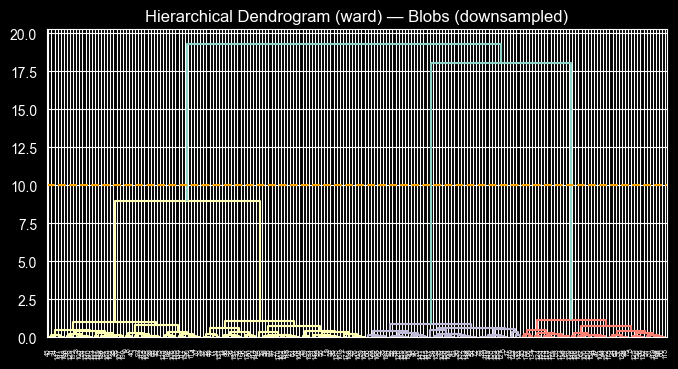

[Agglomerative·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000


In [29]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

idx = np.random.choice(len(X1s), size=200, replace=False)

# method 옵션 (linkage 방식) — 현재 ward 사용 중
# "single"   : 두 군집 간 가장 가까운 점 쌍의 거리 기준 (최소 거리)
#              → 긴 사슬 모양(chaining effect) 발생 위험
#              Z = linkage(X1s[idx], method="single")
# "complete" : 두 군집 간 가장 먼 점 쌍의 거리 기준 (최대 거리)
#              → 군집이 고르게 유지되지만 이상치에 민감
#              Z = linkage(X1s[idx], method="complete")
# "average"  : 두 군집 간 모든 점 쌍 거리의 평균
#              → single과 complete의 중간 특성
#              Z = linkage(X1s[idx], method="average")
# "ward"     : 군집 내 분산(inertia) 증가를 최소화 ← 현재 사용
#              → 균형 잡힌 군집 형성, 실무에서 가장 많이 씀
Z = linkage(X1s[idx], method='ward')

plt.figure(figsize=(8, 4))
dendrogram(Z, color_threshold=10)
plt.title("Hierarchical Dendrogram (ward) — Blobs (downsampled)")
plt.axhline(y=10, color="orange", linestyle="--")
plt.show()

# AgglomerativeClustering linkage 옵션 (위와 동일한 방식)
# linkage="single"   : 최소 거리 기준
# linkage="complete" : 최대 거리 기준
# linkage="average"  : 평균 거리 기준
# linkage="ward"     : 분산 최소화 기준 ← 현재 사용
agg = AgglomerativeClustering(n_clusters=4, linkage='ward').fit(X1s)
lab_agg = agg.labels_
fig = px.scatter(x=X1s[:, 0], y=X1s[:, 1], color=lab_agg.astype(str),
                 title="Agglomerative (ward) — Blobs")
fig.show()
_ = metrics_report(X1s, lab_agg, y_true=y1, name="Agglomerative·Blobs")



- 트리 기반 관계 표현
- cut 위치에 따른 K 결정
- 대규모 데이터 시 다운샘플 시각화 후 전체 라벨링 적용

## 알고리즘 비교

### K-Means vs 계층 군집 (ward)

|        | KMeans | 계층 군집 (ward) |
| ------ | ------ | -------------- |
| K 필요? | 미리 필요 | 나중에 결정 |
| 속도    | 빠름    | 느림 |
| 수정 가능? | 가능  | 불가능 |
| 시각화  | 중심만  | 트리 구조 |

---

### 계층 군집 vs DBSCAN

|           | 계층 군집    | DBSCAN  |
| --------- | -------- | ------- |
| K 필요?   | 안 정해도 됨 | 필요 없음 |
| 모양      | 볼록/타원 잘함 | 자유로운 모양 |
| 노이즈 처리 | 약함     | 강함 |
| 밀도 기반? | 아님     | 맞음 |
| 이상치 자동 제거 | X  | O |

---

### 실무에서 계층 군집은

- **데이터가 작을 때 (수백~수천 건)** → 트리 구조 전체를 보고 K를 나중에 결정할 수 있어 유리
- **탐색적 분석(EDA)** → 덴드로그램으로 데이터 계층 구조를 한눈에 파악
- **K를 모를 때** → 트리를 그려보고 자른 위치로 K를 후결정
- **단, 대용량 데이터엔 비추** → O(n²) 메모리·시간 복잡도로 느림, 대신 샘플링 후 시각화하고 전체는 K-Means 적용하는 패턴 많이 씀


## 5) GMM  확률
- 가우시안 Mixture Model
- 데이터가 여러개의 정규분포(가우시안)들이 섞여 있다라고 가정
- K-Means -> 이거 클러스터 0, 1, 2 등 - Hard Clustering
- 확률 -> Soft

<img src="clustering 자료/gmm_정규분포_혼합_정의.png" width="700" alt="GMM의 핵심 정의: 정규분포와 혼합 (Gaussian Mixture Model)"/>

<img src="clustering 자료/gmm_soft_clustering.png" width="700" alt="핵심 메커니즘: 확률적 소속 (Soft Clustering) — K-Means vs GMM"/>

In [30]:
gmm1 = GaussianMixture(n_components=4, covariance_type="full", random_state=42).fit(X1s)
lab_gmm1 = gmm1.predict(X1s)
proba1 = gmm1.predict_proba(X1s)
fig = px.scatter(x=X1s[:, 0], y=X1s[:, 1], color=lab_gmm1.astype(str),
                 title="GMM on Blobs")
fig.show()
_ = metrics_report(X1s, lab_gmm1, y_true=y1, name="GMM·Blobs")

import numpy.linalg as LA


def add_gmm_ellipses(fig, gmm, n_std=2.0, color="lightgray"):
    for mean, cov in zip(gmm.means_, gmm.covariances_):
        vals, vecs = LA.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        width, height = 2 * n_std * np.sqrt(vals)
        fig.add_shape(
            type="circle", xref="x", yref="y",
            x0=mean[0] - width / 2, y0=mean[1] - height / 2,
            x1=mean[0] + width / 2, y1=mean[1] + height / 2,
            line=dict(color=color, width=1), opacity=0.5
        )
    return fig


fig = px.scatter(x=X1s[:, 0], y=X1s[:, 1], color=lab_gmm1.astype(str),
                 title="GMM with covariance ellipses (~2σ)")
fig = add_gmm_ellipses(fig, gmm1, n_std=2.0, color="lightgray")
fig.show()

gmm2 = GaussianMixture(n_components=2, covariance_type="full", random_state=42).fit(X2s)
lab_gmm2 = gmm2.predict(X2s)
_ = metrics_report(X2s, lab_gmm2, y_true=y2, name="GMM·Moons")

[GMM·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000


[GMM·Moons] k(core)=2 | Sil=0.479 | CH=457.3 | DB=0.829 | ARI=0.423 | NMI=0.334


<img src="clustering 자료/gmm_분포_타원형.png" width="700" alt="분포의 기하학적 형태: 원에서 타원으로 (GMM 타원형 군집)"/>

- 혼합정규 가정 기반 확률 소속
- 공분산 타원(등고선)으로 분포 가정 가시화
- 비정형 데이터에서 가정 위배 가능

## GMM 분포 형태 결정 요소: 분산과 공분산

**분산(Variance)**: 한 변수의 퍼짐 정도 → 타원의 **크기(뚱뚱/홀쭉)** 결정

**공분산(Covariance)**: 두 변수가 함께 움직이는 **방향과 정도**

| 유형 | 방향 | 예시 |
|---|---|---|
| 양의 공분산 | 함께 증가 | 키↑ → 몸무게↑ |
| 음의 공분산 | 반대 방향 | 공부↑ → 게임↓ |
| 공분산 0 | 관계 없음 | 두 변수 독립 |

**결론**: 공분산을 반영하면 군집이 기울어진 **타원형(Ellipse)** 형태 유지 → GMM이 방향성을 포함한 정교한 군집화 가능

<img src="clustering 자료/gmm_비정형_한계.png" width="700" alt="모델의 한계: 비정형 데이터와 가정 위배 (GMM 한계)"/>

## 6) MeanShift 봉우리 중심
- 평균 따라 이동
    - 자연스럽게 중심을 찾는 알고리즘
- K를 우리가 지정할 필요가 없음
- bandwidth: 커널 폭(크면 군집이 합쳐지고, 작으면 과하게 쪼개짐)
- 이 친구는 느려요 데이터 많으면

<img src="clustering 자료/meanshift_작동원리_5단계.png" width="700" alt="평균을 향해, 멈출 때까지 이동합니다 — MeanShift 작동 원리 5단계"/>

<img src="clustering 자료/meanshift_vs_kmeans_K불필요.png" width="700" alt="K를 고민할 필요가 없습니다 — K-Means vs MeanShift"/>

<img src="clustering 자료/meanshift_bandwidth_개념.png" width="700" alt="Bandwidth: 세상을 얼마나 넓게 볼 것인가?"/>

In [31]:
from sklearn.cluster import estimate_bandwidth

bw = estimate_bandwidth(X1s, quantile=0.2, n_samples=200)
ms = MeanShift(bandwidth=bw, bin_seeding=True).fit(X1s)
lab_ms = ms.labels_
fig = px.scatter(x=X1s[:, 0], y=X1s[:, 1], color=lab_ms.astype(str),
                 title=f"MeanShift on Blobs (bandwidth≈{bw:.2f})")
fig.show()
_ = metrics_report(X1s, lab_ms, y_true=y1, name="MeanShift·Blobs")

[MeanShift·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000


## MeanShift 계산 복잡도와 고차원 한계

| 항목 | 내용 |
|---|---|
| 시간 복잡도 | **O(N²)** — 하나의 점을 이동시키기 위해 주변 모든 데이터를 확인 |
| 샘플 수 영향 | N이 커질수록 계산량 기하급수적 증가 → 실시간 처리 부적합 |
| 고차원 문제 | 차원↑ → 점들 간 거리 비슷해짐 → '밀도' 개념 희미 → 봉우리 탐색 어려움 |
| 적합 상황 | 소규모·저차원 데이터, 중심점 탐색이 목적인 경우 |

<img src="clustering 자료/meanshift_고차원_약점.png" width="700" alt="차원의 저주: 고차원에서는 밀도가 사라집니다 (MeanShift 약점)"/>

- 커널폭(bandwidth) 중심 민감
- 클러스터 수 자동 탐색
- 샘플 많거나 고차원 시 계산량 증가

---
### MeanShift vs DBSCAN — 같은 밀도 기반, 다른 철학
> 두 알고리즘의 핵심 철학 차이

<img src="clustering 자료/meanshift_vs_dbscan_밀도기반_비교.png" width="700" alt="같은 밀도 기반, 다른 철학: Enter DBSCAN (MeanShift = Peak Seeker, DBSCAN = Chain Linker)"/>

<img src="clustering 자료/meanshift_vs_dbscan_중심_vs_영토.png" width="700" alt="중심을 찾느냐, 영토를 잇느냐 — MeanShift(Mode 수렴) vs DBSCAN(연결성 확장)"/>

<img src="clustering 자료/meanshift_vs_dbscan_노이즈처리.png" width="700" alt="외톨이 점을 대하는 태도 — Noise Handling (DBSCAN: 버림 / MeanShift: 억지로 포함)"/>

## 파라미터 복잡도 비교

| 구분 | MeanShift | DBSCAN |
|---|---|---|
| 파라미터 수 | 1개 (`bandwidth`) | 2개 (`eps`, `min_samples`) |
| 설정 난이도 | 단순 | 복잡하지만 정교한 제어 가능 |
| 결과 민감도 | bandwidth 하나에 결과 좌우 | eps·min_samples 조합으로 세밀 조정 |
| 특성 | Simple but Sensitive | Complex but Controlled |

## 7. 비교

In [32]:
def run_all_on(X, y_true=None, k_for_kmeans=4, title=""):
    results = []
    km = KMeans(n_clusters=k_for_kmeans, random_state=42, n_init=20).fit(X)
    lab = km.labels_
    results.append(("KMeans", metrics_report(X, lab, y_true=y_true, name=f"KMeans·{title}")))
    eps_default = 0.25 if title == "Moons" else 0.35
    db = DBSCAN(eps=eps_default, min_samples=5).fit(X)
    lab = db.labels_
    results.append(("DBSCAN", metrics_report(X, lab, y_true=y_true, name=f"DBSCAN·{title}")))
    n = max(k_for_kmeans, 2)
    ag = AgglomerativeClustering(n_clusters=n, linkage='ward').fit(X)
    lab = ag.labels_
    results.append(("Agglomerative", metrics_report(X, lab, y_true=y_true, name=f"Agglo·{title}")))
    gm = GaussianMixture(n_components=n, covariance_type="full", random_state=42).fit(X)
    lab = gm.predict(X)
    results.append(("GMM", metrics_report(X, lab, y_true=y_true, name=f"GMM·{title}")))
    bw = estimate_bandwidth(X, quantile=0.2, n_samples=min(200, len(X)))
    ms = MeanShift(bandwidth=bw, bin_seeding=True).fit(X)
    lab = ms.labels_
    results.append(("MeanShift", metrics_report(X, lab, y_true=y_true, name=f"MS·{title}")))
    dfm = pd.DataFrame({name: met for name, met in results}).T
    return dfm

df_blobs = run_all_on(X1s, y_true=y1, k_for_kmeans=4, title="Blobs")
df_moons = run_all_on(X2s, y_true=y2, k_for_kmeans=2, title="Moons")

display(df_blobs.round(3))
display(df_moons.round(3))

[KMeans·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000
[DBSCAN·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000
[Agglo·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000
[GMM·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000
[MS·Blobs] k(core)=4 | Sil=0.859 | CH=7675.7 | DB=0.198 | ARI=1.000 | NMI=1.000
[KMeans·Moons] k(core)=2 | Sil=0.479 | CH=458.4 | DB=0.829 | ARI=0.430 | NMI=0.339
[DBSCAN·Moons] k(core)=2 | Sil=0.381 | CH=292.9 | DB=1.025 | ARI=0.972 | NMI=0.945
[Agglo·Moons] k(core)=2 | Sil=0.463 | CH=432.6 | DB=0.855 | ARI=0.312 | NMI=0.240
[GMM·Moons] k(core)=2 | Sil=0.479 | CH=457.3 | DB=0.829 | ARI=0.423 | NMI=0.334
[MS·Moons] k(core)=3 | Sil=0.364 | CH=292.2 | DB=1.199 | ARI=0.437 | NMI=0.475


,k_core,sil,ch,db,ari,nmi
KMeans,4.0,0.859,7675.732,0.198,1.0,1.0
DBSCAN,4.0,0.859,7675.732,0.198,1.0,1.0
Agglomerative,4.0,0.859,7675.732,0.198,1.0,1.0
GMM,4.0,0.859,7675.732,0.198,1.0,1.0
MeanShift,4.0,0.859,7675.732,0.198,1.0,1.0


,k_core,sil,ch,db,ari,nmi
KMeans,2.0,0.479,458.428,0.829,0.430,0.339
DBSCAN,2.0,0.381,292.875,1.025,0.972,0.945
Agglomerative,2.0,0.463,432.578,0.855,0.312,0.240
GMM,2.0,0.479,457.333,0.829,0.423,0.334
MeanShift,3.0,0.364,292.151,1.199,0.437,0.475


- Blobs: K-Means·Hierarchical·GMM 지표 우수
- Moons: DBSCAN Sil·ARI 우수
> 선택 기준: 데이터 모양·노이즈·해석 요구

---
### 군집 평가지표 해석 원칙
> 지표 선택과 해석 원칙

<img src="clustering 자료/평가지표_지표는_관점.png" width="700" alt="지표는 '진리'가 아니라 '관점'입니다 — 같은 데이터, 다른 지표 결과"/>

<img src="clustering 자료/평가지표_충돌시_판단.png" width="700" alt="지표가 충돌할 때: 무엇을 믿어야 할까? (일관성 → 목적 → 해석 가능성)"/>

<img src="clustering 자료/평가지표_시각화_필수.png" width="700" alt="숫자는 거짓말을 해도, 눈은 속이지 않는다 — 시각화(PCA/UMAP)가 최종 확인 수단"/>

<img src="clustering 자료/평가_최종판단_3요소.png" width="700" alt="최종 판단의 3요소: 수치(Metrics) + 시각화(Visualization) + 해석 가능성(Interpretability)"/>

## 실무 평가지표 Starter Kit

| 단계 | 방법 | 목적 |
|---|---|---|
| 1단계 | Elbow Method로 K 범위 탐색 | 후보 K 선별 |
| 2단계 | Silhouette + Calinski-Harabasz + Davies-Bouldin 계산 | 수치 기반 판단 |
| 3단계 | PCA/UMAP 시각화로 구조 확인 | 직관적 검증 |
| 4단계 | 비즈니스 로직과 대조 | 해석 가능성 확인 |

> **Senior Tip**: 숫자가 아무리 좋아도 비즈니스 로직과 맞지 않으면 탈락. 지표 3개 중 2개 이상 같은 방향일 때 신뢰.

## 정리

| **데이터 형태**   | **추천 알고리즘**  | **핵심 포인트**               |
| ------------ | ------------ | ------------------------ |
| 둥근 / 단순 구조   | K-Means      | 빠르고 단순, k 필요             |
| 비정형 + 이상치 포함 | DBSCAN       | 밀도 기반, 노이즈 감지            |
| 관계·계층 해석     | Hierarchical | 덴드로그램으로 관계 표현            |
| 중첩·확률적 구조    | GMM          | Soft Clustering, 공분산 시각화 |
| 자동 클러스터 수    | MeanShift    | bandwidth 중요, 느림         |

---
### 알고리즘 종합 비교 & 선택 가이드(예외는 있음)

<img src="clustering 자료/알고리즘_총정리_비교표.png" width="700" alt="주요 클러스터링 알고리즘 총정리: K-Means / GMM / MeanShift 비교표"/>

<img src="clustering 자료/meanshift_vs_dbscan_최종비교.png" width="700" alt="MeanShift vs DBSCAN 최종 비교 (속도·중심 탐색·노이즈·형태)"/>

<img src="clustering 자료/알고리즘_선택_의사결정.png" width="700" alt="알고리즘 선택 의사결정 플로우차트 (K-Means → MeanShift → DBSCAN)"/>


#  8 — 실무 응용 & 리포트

### 목표

- 세분화(Clustering) 결과를 검증 가능한 지표와 해석 가능한 시각화로 연결
- 이상치 탐지(DBSCAN + 통계적 Rule) 비교로 실무 내구성 확보
- GMM 확률을 활용해 유사 고객 추천까지 확장
- 한 장 리포트(5줄) 템플릿으로 결과 전달


## 1 데이터 생성 (3개 그룹 + 클리핑)

- Spending, Frequency, Satisfaction 세 개 변수를 가진 가상의 고객 데이터 생성
- 물리적으로 불가능한 값(음수, 5점 이상 등) 클리핑으로 제거

In [33]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

np.random.seed(42)
px.defaults.template = "plotly_dark"
px.defaults.width = 820
px.defaults.height = 480

n = 300
df = pd.DataFrame({
    "Spending": np.concatenate([
        np.random.normal(500, 60, 100),
        np.random.normal(220, 40, 100),
        np.random.normal(90, 25, 100)
    ]),
    "Frequency": np.concatenate([
        np.random.normal(10, 2.0, 100),
        np.random.normal(6, 1.0, 100),
        np.random.normal(3, 0.6, 100)
    ]),
    "Satisfaction": np.concatenate([
        np.random.normal(4.5, 0.35, 100),
        np.random.normal(3.5, 0.4, 100),
        np.random.normal(2.6, 0.45, 100)
    ])
})

df["Spending"] = df["Spending"].clip(lower=0)
df["Frequency"] = df["Frequency"].clip(lower=0)
df["Satisfaction"] = df["Satisfaction"].clip(1, 5)
df.head()

,Spending,Frequency,Satisfaction
0,529.802849,8.342010,4.764946
1,491.704142,8.879638,4.177242
2,538.861312,11.494587,4.804362
3,591.381791,11.220741,4.974473
4,485.950798,9.958197,4.644702


- 데이터는 High/Mid/Low 세 그룹으로 구성
- Spending과 Frequency가 비슷하게 증가하며 Satisfaction이 구분 요인이 됨
- 클리핑으로 음수·5점 초과 방지 → 모델 안정성 확보

## 2. K값 검증 (Elbow + Silhouette + CH + DB)

| **지표**                     | **의미**       | **좋은 방향** |
| -------------------------- | ------------ | --------- |
| **WCSS (Elbow)**           | 군집 내부 거리 제곱합 | 낮을수록      |
| **Silhouette**             | 응집도/분리도      | 높을수록      |
| **CH (Calinski-Harabasz)** | 분리도/응집도 비율   | 높을수록      |
| **DB (Davies-Bouldin)**    | 군집 중첩도       | 낮을수록      |

In [34]:
X = df[["Spending", "Frequency", "Satisfaction"]].values


def eval_kmeans(X, k_list, random_state=42):
    rows = []
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    for k in k_list:
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(Xs)
        rows.append({
            "K": k,
            "WCSS": km.inertia_,
            "Silhouette": silhouette_score(Xs, labels),
            "CH": calinski_harabasz_score(Xs, labels),
            "DB": davies_bouldin_score(Xs, labels)
        })
    return pd.DataFrame(rows)


k_list = list(range(2, 8))
df_k = eval_kmeans(X, k_list)

fig = px.line(df_k, x="K", y=["WCSS", "Silhouette", "CH", "DB"], markers=True,
              title="K 선택 검증 — 낮은 DB, 높은 Sil/CH, 낮아지는 WCSS")
fig.update_layout(yaxis_title="Score (scale differs)")
fig.show()

best_by_sil = int(df_k.loc[df_k["Silhouette"].idxmax(), "K"])
best_by_ch = int(df_k.loc[df_k["CH"].idxmax(), "K"])
print(f"[참고] Silhouette 최고 K={best_by_sil}, CH 최고 K={best_by_ch}")
K_OPT = best_by_sil
print(f"=> K={K_OPT} 채택 (지표 교차 검토 결과)")

[참고] Silhouette 최고 K=2, CH 최고 K=3
=> K=2 채택 (지표 교차 검토 결과)


| **지표**                     | **의미**       | **좋은 방향** |
| -------------------------- | ------------ | --------- |
| **WCSS (Elbow)**           | 군집 내부 거리 제곱합 | 낮을수록      |
| **Silhouette**             | 응집도/분리도      | 높을수록      |
| **CH (Calinski-Harabasz)** | 분리도/응집도 비율   | 높을수록      |
| **DB (Davies-Bouldin)**    | 군집 중첩도       | 낮을수록      |

## 3. K-Means 학습 & 프로파일링

In [35]:
pipe_km = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=K_OPT, n_init=30, random_state=42))
])

labels = pipe_km.fit_predict(X)
df["Cluster"] = labels

profile = df.groupby("Cluster").agg(
    Size=("Spending","size"),
    Spending_mean=("Spending","mean"), Frequency_mean=("Frequency","mean"), Satisfaction_mean=("Satisfaction","mean"),
    Spending_std=("Spending","std"), Frequency_std=("Frequency","std"), Satisfaction_std=("Satisfaction","std")
).round(2)

display(profile)

fig = px.bar(profile.reset_index().melt(id_vars="Cluster",
            value_vars=["Spending_mean","Frequency_mean","Satisfaction_mean"]),
            x="variable", y="value", color="Cluster", barmode="group",
            title="클러스터별 평균 비교")
fig.show()

,Size,Spending_mean,Frequency_mean,Satisfaction_mean,Spending_std,Frequency_std,Satisfaction_std
Cluster,,,,,,,
0,199,155.56,4.43,3.09,72.22,1.73,0.56
1,101,491.81,10.18,4.49,57.68,1.79,0.35


## 4. 시각화 검증 — 3D와 PCA 2D

In [36]:
fig3d = px.scatter_3d(df, x="Spending", y="Frequency", z="Satisfaction",
                      color=df["Cluster"].astype(str), title="3D 시각화")
fig3d.show()

scaler = StandardScaler()
Xs = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(Xs)
df_p = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_p["Cluster"] = df["Cluster"].astype(str)

explained = pca.explained_variance_ratio_.sum()
fig2d = px.scatter(df_p, x="PC1", y="PC2", color="Cluster",
                   title=f"PCA 2D 투영 — 누적 설명력: {explained:.2f}")
fig2d.show()

## 5. 이상치 탐지 — DBSCAN vs IQR

In [37]:
dbscan = Pipeline([
    ("scaler", StandardScaler()),
    ("db", DBSCAN(eps=0.8, min_samples=5))
])
db_labels = dbscan.fit_predict(X)
df["DBSCAN_Label"] = db_labels

fig_db = px.scatter(df, x="Spending", y="Frequency",
                    color=df["DBSCAN_Label"].astype(str),
                    title="DBSCAN 이상치 탐지 (Label=-1: Noise)")
fig_db.show()


def iqr_outlier_flags(s: pd.Series) -> pd.Series:
    q1, q3 = np.percentile(s, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (s < lower) | (s > upper)


iqr_flags = pd.DataFrame({col: iqr_outlier_flags(df[col]) for col in ["Spending", "Frequency", "Satisfaction"]})
df["IQR_Outlier"] = iqr_flags.any(axis=1)

fig_iqr = px.scatter(df, x="Spending", y="Frequency",
                     color=df["IQR_Outlier"].map({True: "IQR Outlier", False: "Inlier"}),
                     title="IQR Rule 이상치 탐지")
fig_iqr.show()

print("DBSCAN 이상치 수:", int((df["DBSCAN_Label"] == -1).sum()))
print("IQR 이상치 수:", int(df["IQR_Outlier"].sum()))

DBSCAN 이상치 수: 1
IQR 이상치 수: 0


- DBSCAN: 밀도 기반, 노이즈(-1) 탐지
- IQR: 단변량 통계 기반, 단순하지만 설명력 높음
- 두 결과 교차
  - AND → 확실한 이상치
  - OR → 재검토 필요 대상

## 6. GMM — Soft Clustering

In [38]:
pipe_gmm = Pipeline([
    ("scaler", StandardScaler()),
    ("gmm", GaussianMixture(n_components=K_OPT, covariance_type="tied", random_state=42))
])
pipe_gmm.fit(X)

gmm_pred   = pipe_gmm.predict(X)
gmm_proba  = pipe_gmm.predict_proba(X)

df["GMM_Cluster"]    = gmm_pred
df["GMM_Confidence"] = gmm_proba.max(axis=1)

fig_gmm = px.scatter_3d(
    df, x="Spending", y="Frequency", z="Satisfaction",
    color=df["GMM_Cluster"].astype(str),
    size="GMM_Confidence",
    title="GMM Soft Clustering (점 크기 = 확신도)"
)
fig_gmm.show()

fig_hist = px.histogram(df, x="GMM_Confidence", nbins=20, title="GMM 확신도 분포")
fig_hist.show()

idx = 0
base_cluster = df.loc[idx, "GMM_Cluster"]
candidates = (
    df[df["GMM_Cluster"] == base_cluster]
    .sort_values("GMM_Confidence", ascending=False)
    .head(5)
)
candidates[["Spending","Frequency","Satisfaction","GMM_Cluster","GMM_Confidence"]]

,Spending,Frequency,Satisfaction,GMM_Cluster,GMM_Confidence
6,594.752769,12.555330,4.229174,1,1.0
73,593.878619,11.918542,4.369996,1,1.0
3,591.381791,11.220741,4.974473,1,1.0
31,611.136691,8.205491,5.000000,1,1.0
71,592.282194,10.995997,3.774313,1,1.0


## 7. 유사 고객 추천 시연

In [39]:
order = df.groupby("Cluster")["Spending"].mean().sort_values(ascending=False).index.tolist()
mapping = {cl: rank for rank, cl in enumerate(order)}
df["ClusterOrdered"] = df["Cluster"].map(mapping)
profile_ord = df.groupby("ClusterOrdered")[["Spending", "Frequency", "Satisfaction"]].mean().round(1)

Xs = StandardScaler().fit_transform(X)
sil = silhouette_score(Xs, labels)
ch = calinski_harabasz_score(Xs, labels)
db = davies_bouldin_score(Xs, labels)

report = f"""
[Segmentation Report]
1. 데이터: Spending/Frequency/Satisfaction 세분화, K={K_OPT}
2. 품질지표: Silhouette={sil:.3f}, CH={ch:.1f}, DB={db:.3f} → 응집·분리 양호
3. 군집 의미:
   - C0 : {profile_ord.iloc[0].to_dict()}
   - C1 :  {profile_ord.iloc[1].to_dict()}
4. 이상치: DBSCAN -1={(df["DBSCAN_Label"] == -1).sum()}건, IQR={df["IQR_Outlier"].sum()}건 → 노이즈 정책 필요
5. 액션: High 리워드, Mid 캠페인, Low 만족 개선/이탈 방지
"""
print(report)


[Segmentation Report]
1. 데이터: Spending/Frequency/Satisfaction 세분화, K=2
2. 품질지표: Silhouette=0.627, CH=807.0, DB=0.514 → 응집·분리 양호
3. 군집 의미:
   - C0 : {'Spending': 491.8, 'Frequency': 10.2, 'Satisfaction': 4.5}
   - C1 :  {'Spending': 155.6, 'Frequency': 4.4, 'Satisfaction': 3.1}
4. 이상치: DBSCAN -1=1건, IQR=0건 → 노이즈 정책 필요
5. 액션: High 리워드, Mid 캠페인, Low 만족 개선/이탈 방지



# 9. PCA + 클러스터링 통합 시각화

### 목표 주성분 분석
- PCA로 고차원 데이터를 2D/3D로 투영하여 구조 시각화
- Scree Plot과 누적 설명력으로 시각화 충실도 검증
- Loadings로 주성분 기여도 해석
- K-Means/DBSCAN과 결합하여 품질·민감도 비교 및 주의점 확인

<img src="clustering 자료/pca_역할_오해.png" width="700" alt="PCA의 역할과 오해: 판별 도구가 아님 — 분산 큰 방향 탐색 & 차원 축소"/>

<img src="clustering 자료/pca_선형_vs_비선형_구조.png" width="700" alt="구조의 정의: 선형(Linear) vs 비선형(Non-linear) 구조"/>

## iris

In [40]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

np.random.seed(42)
px.defaults.template = "plotly_dark"

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

scaler = StandardScaler()
X_s = scaler.fit_transform(X)

## 1) PCA 적합 + Scree Plot
- 각 주성분의 설명력(variance ratio)과 누적 설명력 확인
- 2D/3D 시각화의 충실도 기준 확보
- PCA
    - 사물에 빛 -> 그림자 넓게 퍼짐 -> 그 방향이 데이터의 핵심 구조

> **Scree Plot 읽는 법**  
> "차원을 줄이면 설명력이 줄어든다"가 아니라,  
> **"어디까지 줄여도 괜찮은지"** 를 보여주는 그래프  
> 꺾임점(elbow) 이전까지의 주성분은 정보 손실이 적어 안전하게 선택 가능


In [41]:
pca_full = PCA(n_components=X.shape[1], random_state=42)
X_p = pca_full.fit_transform(X_s)

expl_var = pca_full.explained_variance_ratio_
cum_expl = expl_var.cumsum()

df_scree = pd.DataFrame({
    "PC": np.arange(1, len(expl_var) + 1),
    "ExplainedVar": expl_var,
    "Cumulative": cum_expl
})

fig = go.Figure()
fig.add_trace(go.Bar(x=df_scree["PC"], y=df_scree["ExplainedVar"],
                     name="Explained Variance", marker_color="cyan"))
fig.add_trace(go.Scatter(x=df_scree["PC"], y=df_scree["Cumulative"],
                         mode="lines+markers", name="Cumulative", line_color="orange"))
fig.update_layout(title="Scree Plot — 주성분 설명력",
                  xaxis_title="Principal Component",
                  yaxis_title="Ratio")
fig.show()

exp2_100 = cum_expl[1] * 100.0
exp3_100 = cum_expl[2] * 100.0
print(f"2D 누적 설명력: {exp2_100:.2f}%")
print(f"3D 누적 설명력: {exp3_100:.2f}%")

2D 누적 설명력: 95.81%
3D 누적 설명력: 99.48%


## 2) Loadings 시각화
- 각 변수의 주성분 기여도(PC1~PC3) 확인
- 무엇이 PC를 구성하는지 해석

In [42]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=iris.feature_names,
    columns=[f"PC{i}" for i in range(1, len(expl_var) + 1)]
)

fig = px.imshow(loadings.iloc[:, :3].round(3),
                text_auto=True, color_continuous_scale="RdBu_r",
                title="Feature Loadings (PC1~PC3)")
fig.update_layout(xaxis_title="PC", yaxis_title="Feature")
fig.show()

## 3) 2D/3D 투영 시각화
- 2D: PC1, PC2
- 3D: PC1, PC2, PC3

In [43]:
pca2 = PCA(n_components=2, random_state=42)
X_p2 = pca2.fit_transform(X_s)
exp2 = pca2.explained_variance_ratio_.sum()

df_p2 = pd.DataFrame(X_p2, columns=["PC1", "PC2"])
df_p2["Target"] = y.astype(str)

fig2 = px.scatter(df_p2, x="PC1", y="PC2", color="Target",
                  title=f"PCA 2D — 누적설명력 {exp2 * 100:.1f}%")
fig2.show()

pca3 = PCA(n_components=3, random_state=42)
X_p3 = pca3.fit_transform(X_s)
exp3 = pca3.explained_variance_ratio_.sum()

df_p3 = pd.DataFrame(X_p3, columns=["PC1", "PC2", "PC3"])
df_p3["Target"] = y.astype(str)

fig3 = px.scatter_3d(df_p3, x="PC1", y="PC2", z="PC3", color="Target",
                     title=f"PCA 3D — 누적설명력 {exp3 * 100:.1f}%")
fig3.update_traces(marker=dict(size=4))
fig3.show()

## 4) K-Means: 원본 vs PCA-2D 비교
- Silhouette로 품질 비교
- ARI로 라벨 일치도 확인

In [44]:
def km_eval(X_in, k=3, n_init=20):
    km = KMeans(n_clusters=k, random_state=42, n_init=n_init)
    labels = km.fit_predict(X_in)
    sil = silhouette_score(X_in, labels)
    return labels, sil


lbl_orig, sil_orig = km_eval(X_s, k=3)
lbl_pca, sil_pca = km_eval(X_p2, k=3)
ari = adjusted_rand_score(lbl_orig, lbl_pca)

print(f"[KMeans] Silhouette (Original): {sil_orig:.3f}")
print(f"[KMeans] Silhouette (PCA-2D) : {sil_pca:.3f}")
print(f"[KMeans] ARI (Original vs PCA-2D): {ari:.3f}")

df_p2["KMeans_PCA"] = lbl_pca.astype(str)
fig_km = px.scatter(df_p2, x="PC1", y="PC2", color="KMeans_PCA",
                    title="K-Means on PCA-2D")
fig_km.show()

[KMeans] Silhouette (Original): 0.460
[KMeans] Silhouette (PCA-2D) : 0.509
[KMeans] ARI (Original vs PCA-2D): 1.000


## 5) DBSCAN: 원본 vs PCA-2D 비교
- PCA 투영 시 밀도 구조 변화 가능
- eps 재조정 필요성 체크

In [45]:
def dbscan_labels(X_in, eps, min_samples):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    return db.fit_predict(X_in)


labels_db_orig = dbscan_labels(X_s, eps=0.7, min_samples=5)
labels_db_pca = dbscan_labels(X_p2, eps=0.5, min_samples=5)

n_noise_orig = int((labels_db_orig == -1).sum())
n_noise_pca = int((labels_db_pca == -1).sum())
print(f"[DBSCAN] 노이즈 수 — Original: {n_noise_orig}, PCA-2D: {n_noise_pca}")

df_p2["DBSCAN_PCA"] = labels_db_pca.astype(str)
fig_db = px.scatter(df_p2, x="PC1", y="PC2", color="DBSCAN_PCA",
                    title="DBSCAN on PCA-2D (노이즈=-1)")
fig_db.show()

[DBSCAN] 노이즈 수 — Original: 6, PCA-2D: 12


## 6) 3D

In [46]:
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

pca3 = PCA(n_components=3, random_state=42)
X_p3 = pca3.fit_transform(X_s)
exp3 = pca3.explained_variance_ratio_.sum()

df_p3 = pd.DataFrame(X_p3, columns=["PC1", "PC2", "PC3"])
df_p3["Target"] = y.astype(str)

fig3 = px.scatter_3d(
    df_p3,
    x="PC1", y="PC2", z="PC3",
    color="Target",
    title=f"PCA 3D — 누적설명력 {exp3 * 100:.1f}%",
    template="plotly_dark"
)
fig3.update_traces(marker=dict(size=4))
fig3.show()

# PCA, Clustering 비교

| 구분 | PCA | Clustering |
|------|-----|------------|
| 목적 | 분산이 큰 방향 찾기 | 데이터 그룹 나누기 |
| 역할 | 차원 축소 / 시각화 | 구조 발견 |
| 학습 대상 | X만 사용 | X만 사용 |
| 출력 의미 | 새로운 좌표축 | 그룹 ID |
| 위험한 오해 | "성능을 올려준다" | "정답을 찾는다" |

**중요**

PCA는 군집을 잘 보이게 만들 수는 있지만,
군집의 진짜 품질은 원공간에서 판단해야 함

## 7) 정리
- 시각화 충실도: 누적 설명력
- K-Means 품질/일관성: Silhouette, ARI
- DBSCAN 민감도: 노이즈 변화
- 해석: PC1/PC2를 주도하는 변수
- 권고: 군집은 **원본(표준화) 공간에서 적합**
- PCA는 **시각화/탐색용 도구**
- PCA 후 좋아 보이면 → 반드시 원공간 Silhouette/ARI 재검증

In [47]:
# 코드 무시해주셈.. 귀찮아서.. 도저히 못하겠음
report = []

report.append(f"[설명력] PCA 2D: {exp2_100:.1f}%, 3D: {exp3_100:.1f}% → 2D만으로도 개략 구조 보존 가능")
report.append(f"[K-Means] Silhouette Original={sil_orig:.3f}, PCA-2D={sil_pca:.3f}, 일치도(ARI)={ari:.3f}")
report.append(f"[DBSCAN] PCA-2D 투영 시 노이즈 변화: Original={n_noise_orig}, PCA-2D={n_noise_pca} → eps 재튜닝 필요")

top_loadings = loadings.iloc[:, :2].abs().idxmax()
report.append(f"[해석] PC1/PC2를 가장 크게 구성하는 변수: {top_loadings.to_dict()}")
report.append("[권고] 군집은 원본(표준화) 공간에서 적합, PCA는 시각화/탐색용. 품질은 Silhouette·ARI로 재검증")

print("\n".join(report))

[설명력] PCA 2D: 95.8%, 3D: 99.5% → 2D만으로도 개략 구조 보존 가능
[K-Means] Silhouette Original=0.460, PCA-2D=0.509, 일치도(ARI)=1.000
[DBSCAN] PCA-2D 투영 시 노이즈 변화: Original=6, PCA-2D=12 → eps 재튜닝 필요
[해석] PC1/PC2를 가장 크게 구성하는 변수: {'PC1': 'petal length (cm)', 'PC2': 'sepal width (cm)'}
[권고] 군집은 원본(표준화) 공간에서 적합, PCA는 시각화/탐색용. 품질은 Silhouette·ARI로 재검증


---
## 오늘의 정리

| 개념 | 핵심 | 코드 |
|------|------|------|
| 비지도학습 | 정답 없이 데이터 구조 탐색 | — |
| 유클리드 거리 | 직선 거리 (K-Means 기본) | `np.linalg.norm()`, `cdist()` |
| 맨해튼 거리 | 격자 이동 거리 | `np.sum(np.abs(...))` |
| 코사인 유사도 | 크기 아닌 방향(각도) 유사도 | `np.dot() / np.linalg.norm()` |
| K-Means | 중심 → 할당 → 평균 이동 반복 | `KMeans(n_clusters=k)` |
| Elbow Method | WCSS 감소 둔화 지점 = 최적 K | `kmeans.inertia_` |
| Silhouette Score | 응집도·분리도 평가 (−1 ~ 1) | `silhouette_score()` |
| DBSCAN | 밀도 기반, 노이즈(−1) 자동 탐지 | `DBSCAN(eps, min_samples)` |
| Hierarchical | 계층 트리(덴드로그램)로 K 결정 | `linkage()`, `dendrogram()` |
| GMM | 확률 기반 Soft Clustering | `GaussianMixture()` |
| MeanShift | K 불필요, 봉우리 자동 탐색 | `MeanShift()` |
| 고객 세분화 | 군집 → 행동 패턴 → 전략 수립 | `Pipeline([scaler, kmeans])` |
| 이상치 탐지 | DBSCAN + IQR 교차 검증 | `DBSCAN` + `quantile()` |
| PCA + 군집 | 고차원 → 2D/3D 투영 후 시각화 | `PCA(n_components=2)` |

### 오늘의 핵심 문장

> **군집(Clustering) = 정답 없이 데이터 스스로 구조를 드러내는 과정**  
> 거리 기준으로 비슷한 것끼리 묶고, K값 선택이 성능의 핵심  
> 알고리즘마다 가정이 다르니 — 데이터 형태에 맞는 알고리즘을 선택하자!

### 기억할 흐름

```
EDA (탐색적 데이터 분석)
  → 스케일링 (StandardScaler)
  → K값 선택 (Elbow + Silhouette)
  → 군집화 (K-Means / DBSCAN / GMM 등)
  → 시각화 검증 (2D/3D, PCA)
  → 군집 해석 (프로파일링, 평균·분산 비교)
  → 실무 적용 (이상치 탐지, 추천, 세분화 전략)
```

### 알고리즘 선택 가이드

| 데이터 형태 | 추천 알고리즘 | 핵심 포인트 |
|------------|-------------|------------|
| 구형·응집형 분포 | **K-Means** | 빠르고 직관적, K 사전 지정 필요 |
| 비정형·반달형 | **DBSCAN** | 밀도 기반, 노이즈 자동 탐지 |
| 계층 구조 탐색 | **Hierarchical** | 덴드로그램으로 K 자동 결정 가능 |
| 확률적 소속 필요 | **GMM** | Soft Clustering, 타원형 분포 가정 |
| K 모르는 경우 | **MeanShift** | 자동 K 탐색, 대용량 시 계산 비용 주의 |